In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tejal5kunjir/nepal-flood-and-weather-dataset-2023-2026/CORRECTED_2023_2026_NEPAL_FLOOD_WEATHER_KAGGLE.csv
/kaggle/input/datasets/tejal5kunjir/nepal-flood-and-weather-dataset-2023-2026/nepal_flood_weather_dataset_kaggle_2023_2026.csv


In [2]:
import glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.signal import lfilter
from scipy.stats import mannwhitneyu
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from sklearn.inspection import permutation_importance

In [3]:
df = pd.read_csv('/kaggle/input/datasets/tejal5kunjir/nepal-flood-and-weather-dataset-2023-2026/CORRECTED_2023_2026_NEPAL_FLOOD_WEATHER_KAGGLE.csv')

In [4]:
df.head()

,date,location,river,basin,dhm_station,latitude,longitude,elevation_m,precipitation_mm,soil_moisture_0_100cm_m3m3,rain_mm,temperature_mean_c,dew_point_mean_c,precipitation_hours,relative_humidity_mean_pct,wind_speed_max_kmh,wind_gusts_max_kmh,wind_direction_dominant_deg,river_discharge_m3s
0,2023-01-01 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.315,0.0,12.2,-2.6,0,37,13.9,68.0,187,0.22
1,2023-01-02 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.315,0.0,11.1,-4.8,0,34,13.4,69.8,191,0.21
2,2023-01-03 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.314,0.0,11.5,-10.3,0,22,14.5,72.0,183,0.21
3,2023-01-04 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.314,0.0,9.6,-8.9,0,29,11.2,67.7,187,0.20
4,2023-01-05 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,0.0,0.314,0.0,10.1,-10.2,0,26,7.4,69.8,54,0.20


In [5]:
df.tail()

,date,location,river,basin,dhm_station,latitude,longitude,elevation_m,precipitation_mm,soil_moisture_0_100cm_m3m3,rain_mm,temperature_mean_c,dew_point_mean_c,precipitation_hours,relative_humidity_mean_pct,wind_speed_max_kmh,wind_gusts_max_kmh,wind_direction_dominant_deg,river_discharge_m3s
13385,2026-08-31 00:00:00,Chisapani,Karnali,Karnali,280.00,28.653056,81.286944,2215,16.3,0.392,16.3,28.3,26.2,21,89,7.1,27.7,90,2.22
13386,2026-08-31 00:00:00,Devghat,Narayani,Narayani/Gandak,450.00,27.710000,84.430000,603,42.8,0.361,42.8,28.3,26.5,22,91,9.1,24.8,89,4.43
13387,2026-08-31 00:00:00,Khokana,Bagmati,Bagmati,550.05,27.632222,85.293333,1315,29.8,0.412,29.8,23.4,21.8,17,92,6.9,20.9,317,4.09
13388,2026-08-31 00:00:00,Kusum,West Rapti,Rapti,375.00,28.007500,82.093889,230,20.3,0.419,20.3,27.7,26.3,18,93,9.6,28.8,87,621.30
13389,2026-08-31 00:00:00,Rasuwagadhi,Bhote Koshi,Narayani,446.22,28.271297,85.377649,1749,5.5,0.411,5.5,23.9,20.6,18,82,4.4,33.5,246,3.60


In [6]:
# Function for some data analysis of the data frame
def data_explain(data_frame):
    print("Size of DataFrame",data_frame.size, '\n')
    print("Shape of Data Frame:", data_frame.shape, '\n')
    print(data_frame.info(), '\n')
    print(data_frame.describe(), '\n')
    print("Count of Null Values:",data_frame.isnull().sum(), '\n')
    return 

In [7]:
data_explain(df)

Size of DataFrame 254410 

Shape of Data Frame: (13390, 19) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13390 entries, 0 to 13389
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         13390 non-null  object 
 1   location                     13390 non-null  object 
 2   river                        13390 non-null  object 
 3   basin                        13390 non-null  object 
 4   dhm_station                  13390 non-null  float64
 5   latitude                     13390 non-null  float64
 6   longitude                    13390 non-null  float64
 7   elevation_m                  13390 non-null  int64  
 8   precipitation_mm             13390 non-null  float64
 9   soil_moisture_0_100cm_m3m3   13390 non-null  float64
 10  rain_mm                      13390 non-null  float64
 11  temperature_mean_c           13390 non-null  float64
 12  dew_point_me

In [8]:
# We can see that the data doesn't have any null values
def check_column_types(df):
    """
    Identify object (categorical/text) and numerical columns in a DataFrame.
    Returns a dict and prints a quick summary.
    """
    object_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
    other_cols = [c for c in df.columns if c not in object_cols + numerical_cols]

    print(f"Total columns: {df.shape[1]}\n")

    print(f"Object columns ({len(object_cols)}):")
    for col in object_cols:
        print(f"  - {col:<25} unique values: {df[col].nunique()}")

    print(f"\nNumerical columns ({len(numerical_cols)}):")
    for col in numerical_cols:
        print(f"  - {col:<25} dtype: {df[col].dtype}")

    if other_cols:
        print(f"\nOther columns (datetime, bool, etc.) ({len(other_cols)}):")
        for col in other_cols:
            print(f"  - {col:<25} dtype: {df[col].dtype}")

    return {
        "object": object_cols,
        "numerical": numerical_cols,
        "other": other_cols,
    }

In [9]:
check_column_types(df)

Total columns: 19

Object columns (4):
  - date                      unique values: 1339
  - location                  unique values: 10
  - river                     unique values: 9
  - basin                     unique values: 9

Numerical columns (15):
  - dhm_station               dtype: float64
  - latitude                  dtype: float64
  - longitude                 dtype: float64
  - elevation_m               dtype: int64
  - precipitation_mm          dtype: float64
  - soil_moisture_0_100cm_m3m3 dtype: float64
  - rain_mm                   dtype: float64
  - temperature_mean_c        dtype: float64
  - dew_point_mean_c          dtype: float64
  - precipitation_hours       dtype: int64
  - relative_humidity_mean_pct dtype: int64
  - wind_speed_max_kmh        dtype: float64
  - wind_gusts_max_kmh        dtype: float64
  - wind_direction_dominant_deg dtype: int64
  - river_discharge_m3s       dtype: float64


{'object': ['date', 'location', 'river', 'basin'],
 'numerical': ['dhm_station',
  'latitude',
  'longitude',
  'elevation_m',
  'precipitation_mm',
  'soil_moisture_0_100cm_m3m3',
  'rain_mm',
  'temperature_mean_c',
  'dew_point_mean_c',
  'precipitation_hours',
  'relative_humidity_mean_pct',
  'wind_speed_max_kmh',
  'wind_gusts_max_kmh',
  'wind_direction_dominant_deg',
  'river_discharge_m3s'],
 'other': []}

### Rain-to-River Lag Fingerprints, Soil "Loaded Gun" Effect & a 48-Hour Flood Early-Warning Model

**This project asks five sharper questions:**
1. **River personalities** – which rivers are "flashy" (react in hours) vs "sluggish" (remember rain for weeks)?
2. **Rain-to-river lag fingerprint** – how many days after rain does each river actually respond?
3. **The soil "loaded gun" effect** – does the *same* heavy rain cause a bigger river surge when soil is already saturated?
4. **Anatomy of a flood** – what does the average week before a flood look like?
5. **Early warning** – can we predict flood *onset* 1–2 days ahead, and does it work for a river the model has **never seen**?

In [10]:
df["date"] = pd.to_datetime(df["date"])
df = (df.drop_duplicates(["location", "date"])
        .sort_values(["location", "date"]).reset_index(drop=True))

# short aliases used throughout
RAIN, SOIL, Q = "precipitation_mm", "soil_moisture_0_100cm_m3m3", "river_discharge_m3s"

# sanity check: are dates consecutive per location? (shifts below assume daily rows)
gaps = df.groupby("location")["date"].diff().dt.days.dropna()
print("Max gap between rows (days):", int(gaps.max()))
print(df["date"].min().date(), "->", df["date"].max().date(), "|", df.shape)

Max gap between rows (days): 1
2023-01-01 -> 2026-08-31 | (13390, 19)


## 0. Defining a "flood event"
There is no flood label in the data, so we create one. Rivers differ massively in size, so a single global
threshold would be meaningless. A **flood day** here = discharge above that river's own **95th percentile**.

In [11]:
df["q_thr"] = df.groupby("location")[Q].transform(lambda s: s.quantile(0.95))
df["flood"] = (df[Q] > df["q_thr"]).astype(int)
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

# z-scores per location (so rivers of different sizes are comparable)
for col, name in [(RAIN, "z_rain"), (SOIL, "z_soil"), (Q, "z_q")]:
    g = df.groupby("location")[col]
    df[name] = (df[col] - g.transform("mean")) / g.transform("std")

summary = (df.groupby("location")
             .agg(river=("river", "first"), basin=("basin", "first"),
                  elevation_m=("elevation_m", "first"),
                  flood_days=("flood", "sum"),
                  median_q=(Q, "median"), max_q=(Q, "max"))
             .sort_values("elevation_m"))
summary["peak_to_median"] = summary["max_q"] / summary["median_q"]
summary

,river,basin,elevation_m,flood_days,median_q,max_q,peak_to_median
location,,,,,,,
Chatara,Saptakoshi,Koshi,153,66,0.28,23.27,83.107143
Bhada Bridge,Babai,Babai,157,65,0.20,24.18,120.900000
Belsot,Kamala,Kamala,188,66,11.42,255.45,22.368651
Kusum,West Rapti,Rapti,230,67,16.86,3175.87,188.367141
Devghat,Narayani,Narayani/Gandak,603,67,0.86,20.78,24.162791
Chameliya/Nayalbadi,Chamelia,Mahakali,685,67,14.14,124.60,8.811881
Khokana,Bagmati,Bagmati,1315,67,0.22,57.61,261.863636
Rasuwagadhi,Bhote Koshi,Narayani,1749,67,0.63,8.33,13.222222
Bahrabise,Bhote Koshi,Koshi,1870,67,1.56,33.75,21.634615


## 1. River personalities: flashy vs. sluggish
We use the **Richards–Baker Flashiness Index** (sum of absolute day-to-day change ÷ total flow).
High = violent, quick swings. Low = slow, steady, "heavy" river.

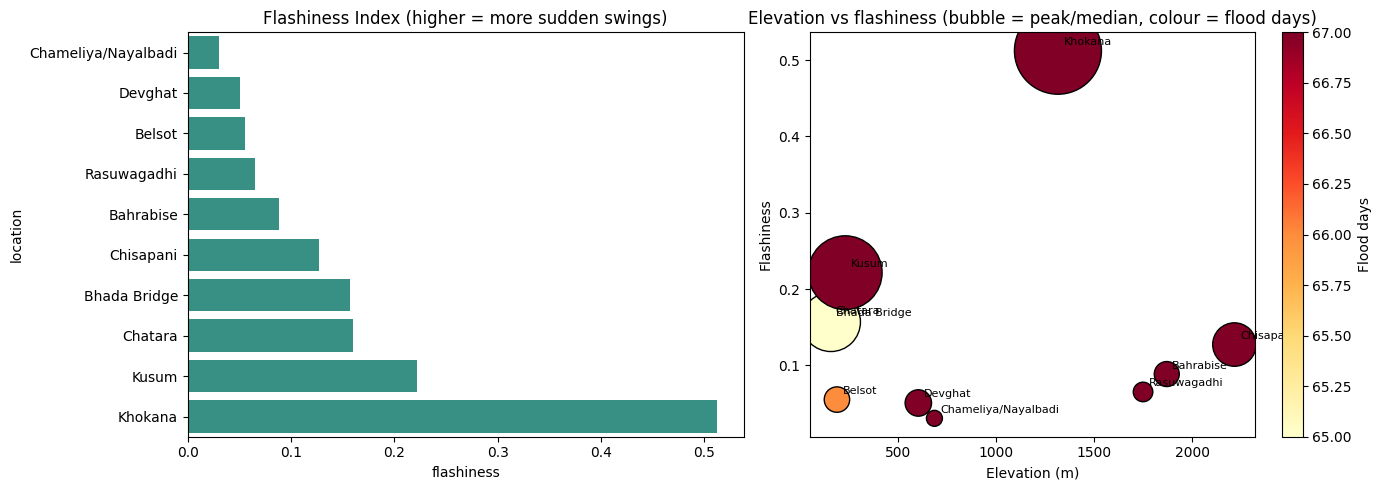

In [12]:
def flashiness(s):
    return s.diff().abs().sum() / s.sum()

summary["flashiness"] = df.groupby("location")[Q].apply(flashiness)
order = summary.sort_values("flashiness").index

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=summary.loc[order, "flashiness"], y=order, ax=ax[0], color="#2a9d8f")
ax[0].set_title("Flashiness Index (higher = more sudden swings)")
sc = ax[1].scatter(summary["elevation_m"], summary["flashiness"], s=summary["peak_to_median"] * 15,
                   c=summary["flood_days"], cmap="YlOrRd", edgecolor="k")
for loc, r in summary.iterrows():
    ax[1].annotate(loc, (r["elevation_m"], r["flashiness"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[1].set_xlabel("Elevation (m)"); ax[1].set_ylabel("Flashiness")
ax[1].set_title("Elevation vs flashiness (bubble = peak/median, colour = flood days)")
plt.colorbar(sc, ax=ax[1], label="Flood days")
plt.tight_layout(); plt.show()

## 2. The rain-to-river lag fingerprint
For each location: correlation between rainfall *k days ago* and today's **change** in discharge.
The lag with the strongest correlation is the river's **response time**.

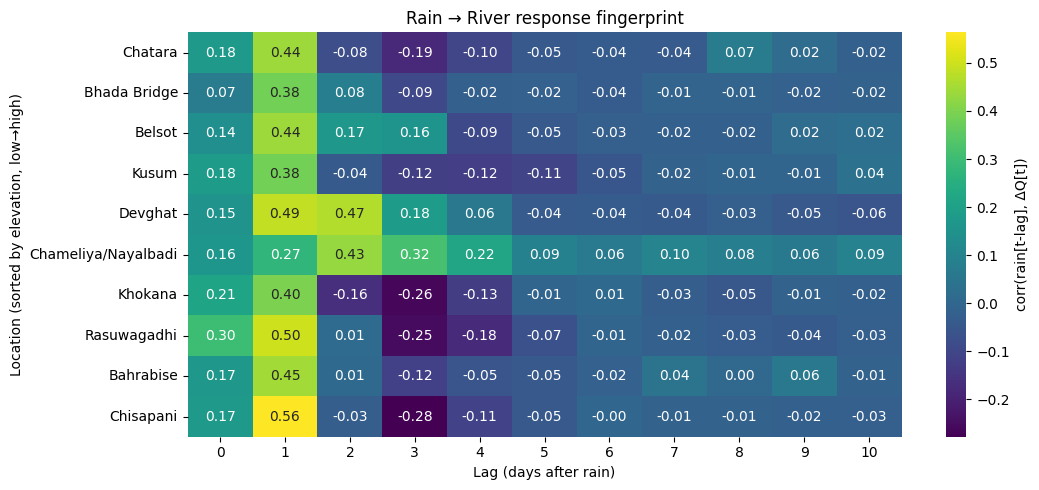

,river,elevation_m,response_lag_days
location,,,
Chatara,Saptakoshi,153,1
Bhada Bridge,Babai,157,1
Belsot,Kamala,188,1
Kusum,West Rapti,230,1
Devghat,Narayani,603,1
Chameliya/Nayalbadi,Chamelia,685,2
Khokana,Bagmati,1315,1
Rasuwagadhi,Bhote Koshi,1749,1
Bahrabise,Bhote Koshi,1870,1


In [13]:
MAX_LAG = 10
fp = {}
for loc, g in df.groupby("location"):
    dq = g[Q].diff()
    fp[loc] = [g[RAIN].shift(k).corr(dq) for k in range(MAX_LAG + 1)]
fp = pd.DataFrame(fp, index=range(MAX_LAG + 1)).T
fp = fp.loc[summary.index]  # sorted by elevation

summary["response_lag_days"] = fp.idxmax(axis=1)

plt.figure(figsize=(11, 5))
sns.heatmap(fp, cmap="viridis", annot=True, fmt=".2f", cbar_kws={"label": "corr(rain[t-lag], ΔQ[t])"})
plt.xlabel("Lag (days after rain)"); plt.ylabel("Location (sorted by elevation, low→high)")
plt.title("Rain → River response fingerprint")
plt.tight_layout(); plt.show()
summary[["river", "elevation_m", "response_lag_days"]]

## 3. The soil "loaded gun" effect
**Hypothesis:** identical heavy rain is far more dangerous when the soil is already saturated.
Test: take only **heavy-rain days** (top 10% of rain within each location), split by soil wetness
(within-location percentile: Dry / Medium / Wet) and measure the discharge surge over the next 3 days.

Heavy-rain days: 1325


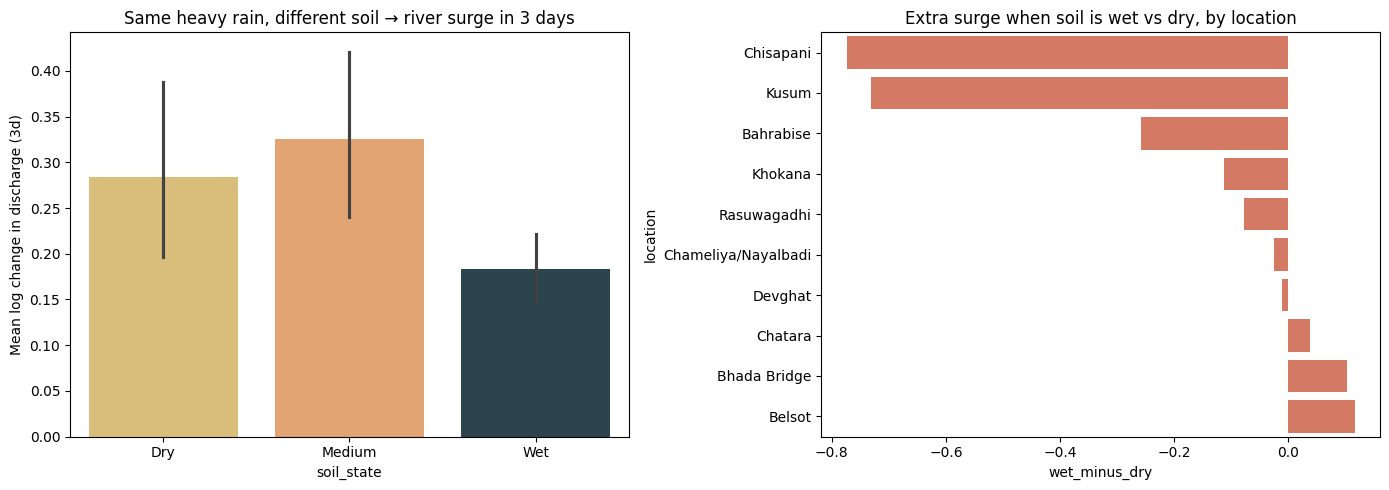

Mann–Whitney (Wet > Dry): p = 0.9986


In [14]:
g = df.groupby("location")
df["rain_pct"] = g[RAIN].rank(pct=True)
df["soil_pct"] = g[SOIL].rank(pct=True)
df["surge_3d"] = np.log((g[Q].shift(-3) + 1e-6) / (df[Q] + 1e-6))   # log change in flow after 3 days
df["soil_state"] = pd.cut(df["soil_pct"], [0, .33, .66, 1.0], labels=["Dry", "Medium", "Wet"], include_lowest=True)

heavy = df[(df["rain_pct"] >= 0.90) & (df[RAIN] > 0)].dropna(subset=["surge_3d"])
print("Heavy-rain days:", len(heavy))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=heavy, x="soil_state", y="surge_3d", hue='soil_state', order=["Dry", "Medium", "Wet"],
            palette=["#e9c46a", "#f4a261", "#264653"], errorbar=("ci", 95), ax=ax[0])
ax[0].set_title("Same heavy rain, different soil → river surge in 3 days")
ax[0].set_ylabel("Mean log change in discharge (3d)")

pivot = heavy.pivot_table(index="location", columns="soil_state", values="surge_3d", aggfunc="mean", observed=False)
pivot["wet_minus_dry"] = pivot["Wet"] - pivot["Dry"]
sns.barplot(x=pivot["wet_minus_dry"].sort_values(), y=pivot["wet_minus_dry"].sort_values().index,
            color="#e76f51", ax=ax[1])
ax[1].set_title("Extra surge when soil is wet vs dry, by location")
plt.tight_layout(); plt.show()

wet, dry = heavy.loc[heavy.soil_state == "Wet", "surge_3d"], heavy.loc[heavy.soil_state == "Dry", "surge_3d"]
if len(wet) > 5 and len(dry) > 5:
    print(f"Mann–Whitney (Wet > Dry): p = {mannwhitneyu(wet, dry, alternative='greater').pvalue:.4f}")

Heavy-rain days: 1325 | monsoon (Jun-Sep): 1135


,term,n,coef,ci_low,ci_high,p_value
model,,,,,,
All heavy-rain days,soil_az,1325,0.0111,-0.0246,0.0468,0.5427
Monsoon only (Jun-Sep),soil_az,1135,0.0251,-0.0127,0.0629,0.1933
"Monsoon, soil x rain interaction",soil_az:log_rain,1135,0.1274,0.0073,0.2476,0.0376



soil_az coefficient when each river is dropped:
 Chatara                0.007
Bhada Bridge           0.020
Devghat                0.020
Chameliya/Nayalbadi    0.023
Chisapani              0.026
Kusum                  0.026
Khokana                0.029
Rasuwagadhi            0.031
Bahrabise              0.032
Belsot                 0.037
dtype: float64


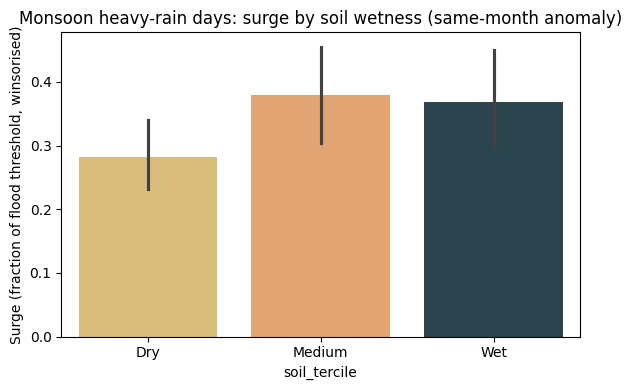

In [15]:
import statsmodels.formula.api as smf

RAIN, SOIL, Q = "precipitation_mm", "soil_moisture_0_100cm_m3m3", "river_discharge_m3s"

# 1) soil anomaly relative to that location's usual soil for the same month, in SD units
df["soil_anom"] = df[SOIL] - df.groupby(["location", "month"])[SOIL].transform("mean")
df["soil_az"] = df["soil_anom"] / df.groupby("location")["soil_anom"].transform("std")

# 2) outcome: how much does flow RISE in days t..t+3, as a fraction of that river's flood threshold
g = df.groupby("location")
future = pd.concat([g[Q].shift(-k) for k in (0, 1, 2, 3)], axis=1)
df["surge_frac"] = (future.max(axis=1, skipna=False) - g[Q].shift(1)) / df["q_thr"]

# 3) heavy-rain days only, outcome winsorised (Kusum's 3000+ m3/s spike would otherwise dominate)
df["rain_pct"] = df.groupby("location")[RAIN].rank(pct=True)
h = df[(df["rain_pct"] >= 0.90) & (df[RAIN] > 0)].dropna(subset=["surge_frac", "soil_az"]).copy()
lo, hi = h["surge_frac"].quantile([0.01, 0.99])
h["y"] = h["surge_frac"].clip(lo, hi)
h["log_rain"] = np.log(h[RAIN])
h["storm"] = pd.factorize(h["date"].dt.strftime("%G-%V"))[0]     # ISO year-week = cluster id
print("Heavy-rain days:", len(h), "| monsoon (Jun-Sep):", int(h["month"].between(6, 9).sum()))

def fit_cluster(d, formula):
    return smf.ols(formula, d).fit(cov_type="cluster", cov_kwds={"groups": d["storm"].values})

mon = h[h["month"].between(6, 9)]
specs = [("All heavy-rain days",            "y ~ soil_az + log_rain + C(location)",  h,   "soil_az"),
         ("Monsoon only (Jun-Sep)",         "y ~ soil_az + log_rain + C(location)",  mon, "soil_az"),
         ("Monsoon, soil x rain interaction", "y ~ soil_az * log_rain + C(location)", mon, "soil_az:log_rain")]
rows = []
for name, f, d, term in specs:
    r = fit_cluster(d, f)
    ci = r.conf_int().loc[term]
    rows.append({"model": name, "term": term, "n": int(r.nobs), "coef": r.params[term],
                 "ci_low": ci[0], "ci_high": ci[1], "p_value": r.pvalues[term]})
soil_res = pd.DataFrame(rows).set_index("model")
display(soil_res.round(4))
# coef for soil_az = extra surge (in units of the flood threshold) per +1 SD of soil wetness,
# same river, same rain amount. CI containing 0 => no detectable "loaded gun" effect.

# Is one river driving the answer? Drop each location in turn (monsoon-only model)
loo = {}
for loc in mon["location"].unique():
    d = mon[mon["location"] != loc]
    loo[loc] = fit_cluster(d, "y ~ soil_az + log_rain + C(location)").params["soil_az"]
print("\nsoil_az coefficient when each river is dropped:\n", pd.Series(loo).round(3).sort_values())

# Plot: mean surge by soil tercile, monsoon days only (the fair comparison)
mon = mon.assign(soil_tercile=pd.qcut(mon["soil_az"], 3, labels=["Dry", "Medium", "Wet"]))
plt.figure(figsize=(6, 4))
sns.barplot(data=mon, x="soil_tercile", y="y", hue="soil_tercile", errorbar=("ci", 95),
            palette=["#e9c46a", "#f4a261", "#264653"], legend=False)
plt.ylabel("Surge (fraction of flood threshold, winsorised)")
plt.title("Monsoon heavy-rain days: surge by soil wetness (same-month anomaly)")
plt.tight_layout(); plt.show()


## 4. Anatomy of a flood
Align every flood **onset** (first day of a flood run) at day 0 and average standardised rain, soil moisture
and discharge from 7 days before to 3 days after.

Flood onset events: 161


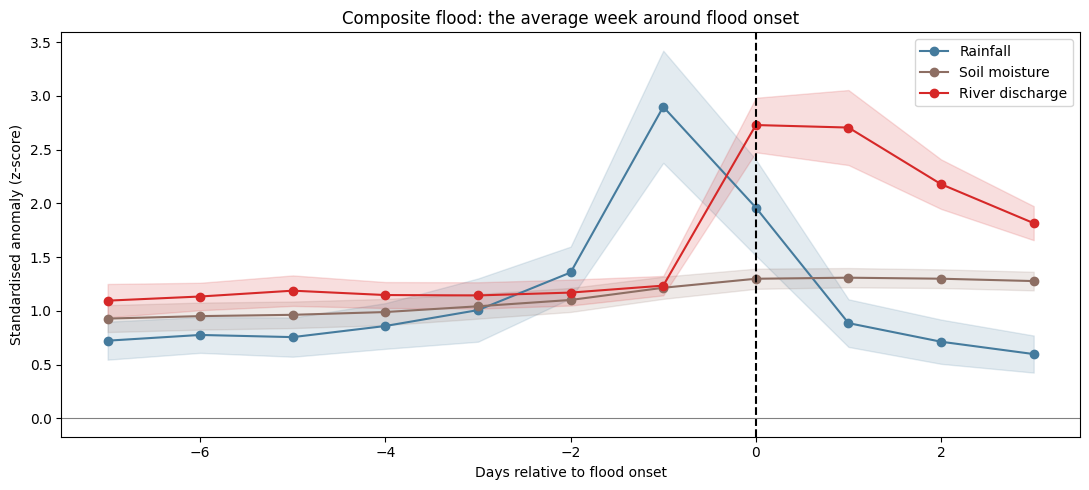

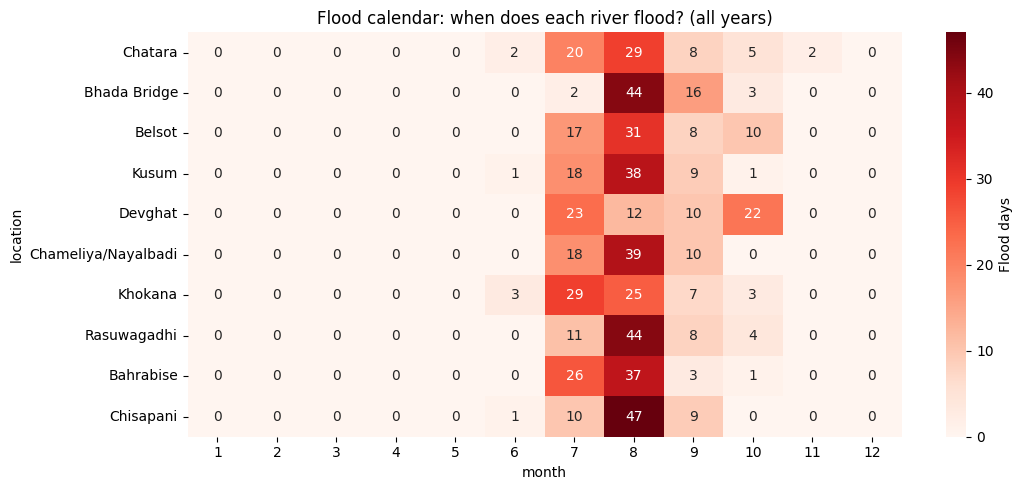

In [16]:
df["prev_flood"] = df.groupby("location")["flood"].shift(1).fillna(0)
onset = (df["flood"] == 1) & (df["prev_flood"] == 0)
print("Flood onset events:", int(onset.sum()))

rows = []
for off in range(-7, 4):
    for col, label in [("z_rain", "Rainfall"), ("z_soil", "Soil moisture"), ("z_q", "River discharge")]:
        vals = df.groupby("location")[col].shift(-off)[onset].dropna()
        rows.append({"day": off, "variable": label, "mean_z": vals.mean(), "sem": vals.sem()})
comp = pd.DataFrame(rows)

plt.figure(figsize=(11, 5))
for label, c in zip(["Rainfall", "Soil moisture", "River discharge"], ["#457b9d", "#8d6e63", "#d62828"]):
    s = comp[comp.variable == label]
    plt.plot(s["day"], s["mean_z"], marker="o", label=label, color=c)
    plt.fill_between(s["day"], s["mean_z"] - 1.96 * s["sem"], s["mean_z"] + 1.96 * s["sem"], color=c, alpha=.15)
plt.axvline(0, color="k", ls="--"); plt.axhline(0, color="grey", lw=.8)
plt.xlabel("Days relative to flood onset"); plt.ylabel("Standardised anomaly (z-score)")
plt.title("Composite flood: the average week around flood onset")
plt.legend(); plt.tight_layout(); plt.show()

# Seasonal flood calendar
cal = df.pivot_table(index="location", columns="month", values="flood", aggfunc="sum").loc[summary.index]
plt.figure(figsize=(11, 5))
sns.heatmap(cal, cmap="Reds", annot=True, fmt=".0f", cbar_kws={"label": "Flood days"})
plt.title("Flood calendar: when does each river flood? (all years)")
plt.tight_layout(); plt.show()

## 5. Early-warning model: predict flood **onset** in the next 1–2 days
- **Target:** flood occurs on day *t+1* or *t+2* **given it is not already flooding today** (a harder, more useful task than "is it flooding now?").
- **Features:** antecedent precipitation index (API – the river's "memory of rain"), multi-day rain sums,
  soil moisture & trend, humidity, dew-point spread, discharge trend & ratio to normal, season.
- **Split:** strictly by time (train < 2025, test ≥ 2025) – no leakage from the future.
- **Ablation:** weather-only vs discharge-only vs both.

In [17]:
def api(x, k=0.85):
    return lfilter([1], [1, -k], x.values)   # API_t = rain_t + k * API_{t-1}

g = df.groupby("location")
df["api"] = g[RAIN].transform(api)
for w in (3, 7, 14):
    df[f"rain_{w}d"] = g[RAIN].transform(lambda s: s.rolling(w, min_periods=1).sum())
df["soil_chg_3d"] = g[SOIL].diff(3)
df["dew_spread"] = df["temperature_mean_c"] - df["dew_point_mean_c"]
df["q_lag1"] = g[Q].shift(1)
df["q_chg_1d"] = df[Q] - df["q_lag1"]
df["q_chg_3d"] = df[Q] - g[Q].shift(3)
df["q_ratio_med"] = df[Q] / g[Q].transform("median")
df["q_to_thr"] = df[Q] / df["q_thr"]                      # how close to flood level (>1 = flood)
df["doy_sin"] = np.sin(2 * np.pi * df["date"].dt.dayofyear / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * df["date"].dt.dayofyear / 365.25)

f1, f2 = g["flood"].shift(-1), g["flood"].shift(-2)
df["target"] = ((f1 == 1) | (f2 == 1)).astype(float)
df.loc[f1.isna() | f2.isna(), "target"] = np.nan

WEATHER = ["api", "rain_3d", "rain_7d", "rain_14d", SOIL, "soil_chg_3d", "relative_humidity_mean_pct",
           "dew_spread", "precipitation_hours", "wind_gusts_max_kmh", "temperature_mean_c", "doy_sin", "doy_cos"]
DISCH = [Q, "q_chg_1d", "q_chg_3d", "q_ratio_med", "q_to_thr"]
STATIC = ["elevation_m"]

model_df = df[(df["flood"] == 0)].dropna(subset=["target"] + WEATHER + DISCH + STATIC).copy()
CUTOFF = pd.Timestamp("2025-01-01")
train, test = model_df[model_df.date < CUTOFF], model_df[model_df.date >= CUTOFF]
print(f"Train rows {len(train)} (positives {int(train.target.sum())}) | "
      f"Test rows {len(test)} (positives {int(test.target.sum())})")

def make_model():
    return HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=300,
                                          l2_regularization=1.0, class_weight="balanced", random_state=42)

feature_sets = {"Weather only": WEATHER + STATIC,
                "Discharge only": DISCH + STATIC,
                "Weather + Discharge": WEATHER + DISCH + STATIC}
results, preds = {}, {}
for name, feats in feature_sets.items():
    m = make_model().fit(train[feats], train["target"])
    p = m.predict_proba(test[feats])[:, 1]
    preds[name] = p
    results[name] = {"PR-AUC": average_precision_score(test["target"], p),
                     "ROC-AUC": roc_auc_score(test["target"], p)}
res = pd.DataFrame(results).T
res.loc["Random baseline", "PR-AUC"] = test["target"].mean()
res

Train rows 6870 (positives 176) | Test rows 5806 (positives 126)


,PR-AUC,ROC-AUC
Weather only,0.257025,0.931647
Discharge only,0.151452,0.912295
Weather + Discharge,0.350402,0.948826
Random baseline,0.021702,NaN


In [18]:
CUTOFF = pd.Timestamp("2025-01-01")

def make_model():
    return HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=300,
                                          l2_regularization=1.0, class_weight="balanced", random_state=42)

# --- train-only definitions of "flood" and "normal"
train_part = df[df["date"] < CUTOFF]
thr_tr = train_part.groupby("location")[Q].quantile(0.95)
med_tr = train_part.groupby("location")[Q].median()
df["q_thr_tr"] = df["location"].map(thr_tr)
df["flood_tr"] = (df[Q] > df["q_thr_tr"]).astype(int)
df["q_to_thr_tr"] = df[Q] / df["q_thr_tr"]
df["q_ratio_med_tr"] = df[Q] / df["location"].map(med_tr)
print("Flood-day share  train: %.3f | test: %.3f" %
      (df.loc[df.date < CUTOFF, "flood_tr"].mean(), df.loc[df.date >= CUTOFF, "flood_tr"].mean()))

# --- targets. y_tH = 1 if the FIRST flood day of a run falls exactly H days ahead
#     (no flood today or in between). NaN = not eligible (already flooding / past end of data).
gf = df.groupby("location")["flood_tr"]

def first_flood(H):
    window = pd.concat([gf.shift(-k) for k in range(H)], axis=1)      # days t .. t+H-1
    ok = window.notna().all(axis=1) & (window.sum(axis=1) == 0)
    return gf.shift(-H).where(ok)

for H in (1, 2, 3):
    df[f"y_t{H}"] = first_flood(H)
f1, f2 = gf.shift(-1), gf.shift(-2)                                    # your original "within 2 days"
df["y_within2"] = ((f1 == 1) | (f2 == 1)).astype(float).where(f1.notna() & f2.notna() & (df["flood_tr"] == 0))

# --- feature sets. Every set includes season, so we measure what weather/discharge add BEYOND the calendar.
SEASON = ["doy_sin", "doy_cos"]
WX = [f for f in WEATHER if f not in SEASON]
DQ = [Q, "q_chg_1d", "q_chg_3d", "q_ratio_med_tr", "q_to_thr_tr"]
SETS = {"Season only":                  SEASON,
        "Season + Discharge":           SEASON + DQ,
        "Season + Weather":             SEASON + WX,
        "Season + Weather + Discharge": SEASON + WX + DQ}
FULL = SETS["Season + Weather + Discharge"]

def block_bootstrap(y, P, blocks, n_boot=300, seed=0):
    """Resample whole months (all rivers together). Same resample for every model -> paired differences."""
    rng = np.random.default_rng(seed)
    idx = [np.where(blocks == b)[0] for b in np.unique(blocks)]
    out = {k: [] for k in P}
    for _ in range(n_boot):
        pick = np.concatenate([idx[i] for i in rng.integers(0, len(idx), len(idx))])
        if y[pick].sum() == 0:
            continue
        for k, p in P.items():
            out[k].append(average_precision_score(y[pick], p[pick]))
    return {k: np.array(v) for k, v in out.items()}

COMPARE = [("Season + Weather + Discharge", "Season + Discharge"),
           ("Season + Weather",             "Season + Discharge"),
           ("Season + Weather + Discharge", "Season + Weather"),
           ("Season + Discharge",           "Season only"),
           ("Season + Weather",             "Season only")]
res_rows, diff_rows = [], []
for tname in ["y_t1", "y_t2", "y_t3", "y_within2"]:
    d = df.dropna(subset=[tname] + FULL).copy()
    tr, te = d[d["date"] < CUTOFF], d[d["date"] >= CUTOFF]
    y = te[tname].values
    P = {k: make_model().fit(tr[f], tr[tname]).predict_proba(te[f])[:, 1] for k, f in SETS.items()}
    boot = block_bootstrap(y, P, te["date"].dt.to_period("M").astype(str).values)
    for k in SETS:
        lo_, hi_ = np.percentile(boot[k], [2.5, 97.5])
        res_rows.append({"target": tname, "model": k, "PR_AUC": average_precision_score(y, P[k]),
                         "ci_low": lo_, "ci_high": hi_, "base_rate": y.mean(),
                         "test_pos": int(y.sum()), "train_pos": int(tr[tname].sum())})
    for a, b in COMPARE:
        dl = boot[a] - boot[b]
        diff_rows.append({"target": tname, "A minus B": f"{a}  -  {b}", "mean_diff": dl.mean(),
                          "ci_low": np.percentile(dl, 2.5), "ci_high": np.percentile(dl, 97.5),
                          "P(A>B)": (dl > 0).mean()})
horizon_res = pd.DataFrame(res_rows)
diff_res = pd.DataFrame(diff_rows)
display(horizon_res.pivot(index="model", columns="target", values="PR_AUC").loc[list(SETS)].round(3))
display(horizon_res.groupby("target")[["base_rate", "test_pos", "train_pos"]].first().round(4))
display(diff_res.round(3))
# Read it as: does the CI of "A minus B" exclude 0? Does Weather's advantage over Discharge-only
# GROW from t+1 to t+3? That growth (not the pooled PR-AUC) is the evidence for added lead time.


Flood-day share  train: 0.050 | test: 0.039


target,y_t1,y_t2,y_t3,y_within2
model,,,,
Season only,0.041,0.036,0.033,0.070
Season + Discharge,0.142,0.053,0.039,0.134
Season + Weather,0.236,0.096,0.062,0.236
Season + Weather + Discharge,0.286,0.084,0.124,0.306


,base_rate,test_pos,train_pos
target,,,
y_t1,0.0101,59,96
y_t2,0.0090,52,80
y_t3,0.0086,49,74
y_within2,0.0191,111,176


,target,A minus B,mean_diff,ci_low,ci_high,P(A>B)
0,y_t1,Season + Weather + Discharge - Season + Disc...,0.147,-0.008,0.349,0.967
1,y_t1,Season + Weather - Season + Discharge,0.094,-0.082,0.307,0.877
2,y_t1,Season + Weather + Discharge - Season + Weather,0.053,-0.037,0.121,0.907
3,y_t1,Season + Discharge - Season only,0.108,0.036,0.229,1.000
4,y_t1,Season + Weather - Season only,0.203,0.117,0.360,1.000
5,y_t2,Season + Weather + Discharge - Season + Disc...,0.034,0.015,0.058,1.000
6,y_t2,Season + Weather - Season + Discharge,0.044,-0.008,0.115,0.903
7,y_t2,Season + Weather + Discharge - Season + Weather,-0.011,-0.058,0.033,0.353
8,y_t2,Season + Discharge - Season only,0.015,-0.026,0.047,0.800
9,y_t2,Season + Weather - Season only,0.059,0.016,0.102,0.993


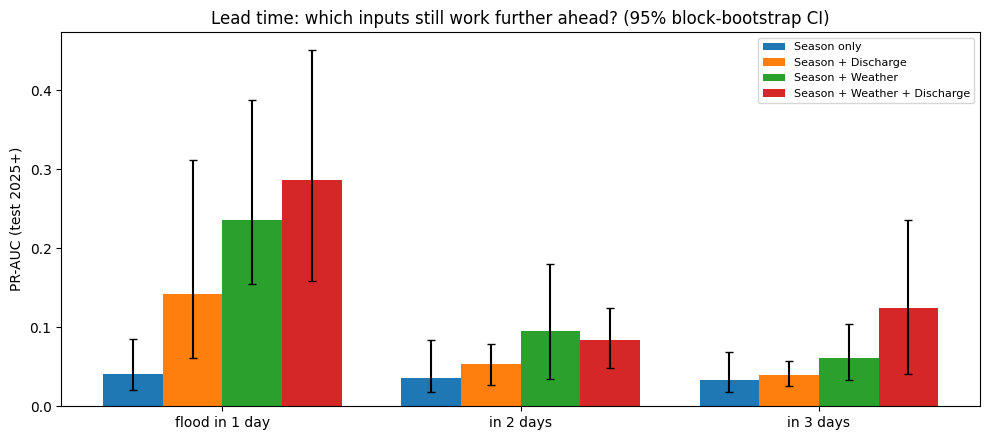

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.5))
tg = ["y_t1", "y_t2", "y_t3"]
width = 0.2
for i, k in enumerate(SETS):
    s = horizon_res[(horizon_res.model == k) & horizon_res.target.isin(tg)].set_index("target").loc[tg]
    ax.bar(np.arange(3) + i * width, s["PR_AUC"], width,
           yerr=[s["PR_AUC"] - s["ci_low"], s["ci_high"] - s["PR_AUC"]], capsize=3, label=k)
ax.set_xticks(np.arange(3) + 1.5 * width); ax.set_xticklabels(["flood in 1 day", "in 2 days", "in 3 days"])
ax.set_ylabel("PR-AUC (test 2025+)"); ax.set_title("Lead time: which inputs still work further ahead? (95% block-bootstrap CI)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

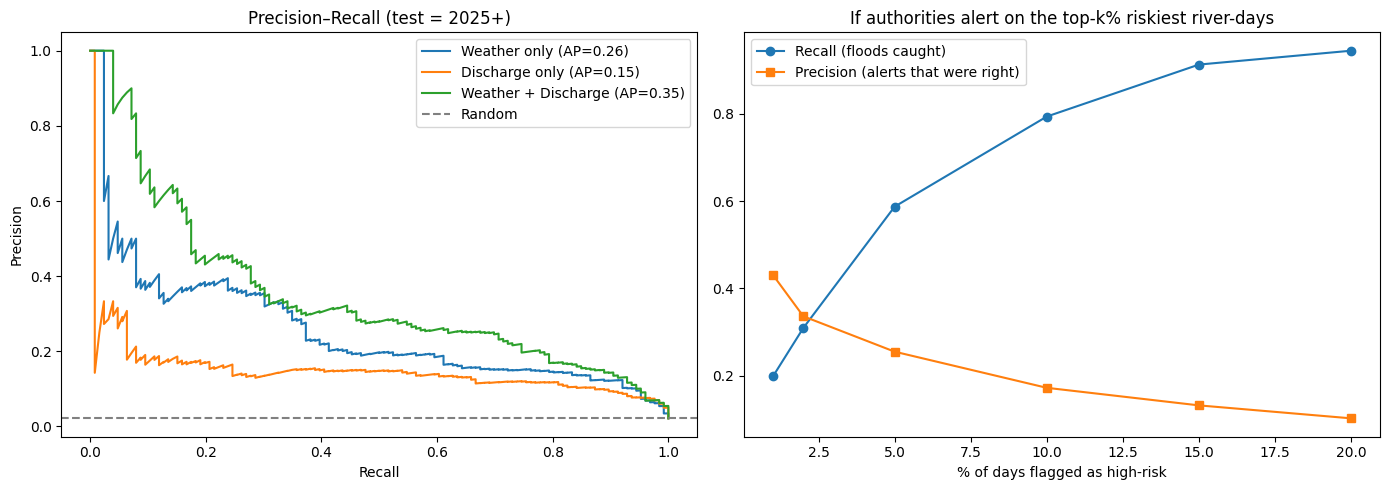

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for name, p in preds.items():
    pr, rc, _ = precision_recall_curve(test["target"], p)
    ax[0].plot(rc, pr, label=f"{name} (AP={results[name]['PR-AUC']:.2f})")
ax[0].axhline(test["target"].mean(), color="grey", ls="--", label="Random")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision"); ax[0].set_title("Precision–Recall (test = 2025+)")
ax[0].legend()

# Operational view: flag the top-k% riskiest days each day
best = preds["Weather + Discharge"]
ranked = test.assign(score=best).sort_values("score", ascending=False)
ks, prec, rec = [1, 2, 5, 10, 15, 20], [], []
for k in ks:
    top = ranked.head(int(len(ranked) * k / 100))
    prec.append(top["target"].mean()); rec.append(top["target"].sum() / test["target"].sum())
ax[1].plot(ks, rec, marker="o", label="Recall (floods caught)")
ax[1].plot(ks, prec, marker="s", label="Precision (alerts that were right)")
ax[1].set_xlabel("% of days flagged as high-risk"); ax[1].set_title("If authorities alert on the top-k% riskiest river-days")
ax[1].legend()
plt.tight_layout(); plt.show()

### What does the model rely on?

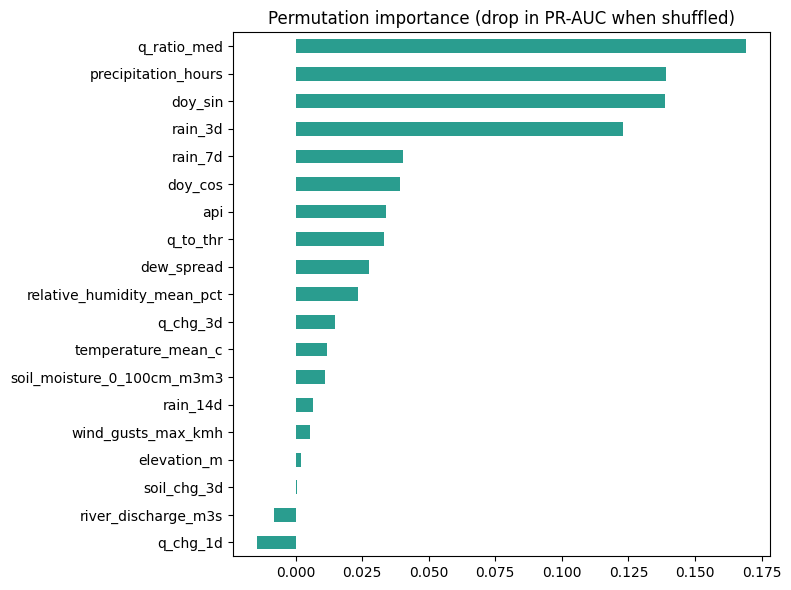

In [21]:
feats = feature_sets["Weather + Discharge"]
m_full = make_model().fit(train[feats], train["target"])
pi = permutation_importance(m_full, test[feats], test["target"], scoring="average_precision",
                            n_repeats=10, random_state=0)
imp = pd.Series(pi.importances_mean, index=feats).sort_values()
plt.figure(figsize=(8, 6))
imp.plot.barh(color="#2a9d8f")
plt.title("Permutation importance (drop in PR-AUC when shuffled)")
plt.tight_layout(); plt.show()

## 6. The stress test: warn a river the model has never seen
Leave-one-location-out: train on 9 locations, test on the 10th. If this works, the model learned
*physics of floods* (rain, soil, trend), not just memorised each river.

positives                     PR_AUC_full  \
scheme              spatial + temporal spatial only spatial + temporal   
held_out                                                                 
Belsot                             9.0         19.0              0.221   
Bhada Bridge                       7.0         21.0              0.270   
Chameliya/Nayalbadi                7.0         21.0              0.360   
Chisapani                          7.0         28.0              0.230   
Khokana                           25.0         54.0              0.465   
Koshi system                      24.0         65.0              0.297   
Kusum                             14.0         34.0              0.369   
Narayani system                   18.0         45.0              0.366   

                                 PR_AUC_season_only               \
scheme              spatial only spatial + temporal spatial only   
held_out                                                           
Belsot                     0.475              0.067        0.129   
Bhada Bridge               0.460              0.052        0.273   
Chameliya/Nayalbadi        0.428              0.063        0.121   
Chisapani                  0.546              0.059        0.213   
Khokana                    0.371              0.212        0.247   
Koshi system               0.440              0.090        0.188   
Kusum                      0.420              0.158        0.198   
Narayani system            0.386              0.039        0.099   

                             lift_full               
scheme              spatial + temporal spatial only  
held_out                                             
Belsot                          13.992       31.505  
Bhada Bridge                    22.739       28.064  
Chameliya/Nayalbadi             27.921       25.128  
Chisapani                       18.911       24.691  
Khokana                         10.902        8.774  
Koshi system                    14.587       17.333  
Kusum                           15.456       15.779  
Narayani system                 24.304       22.091

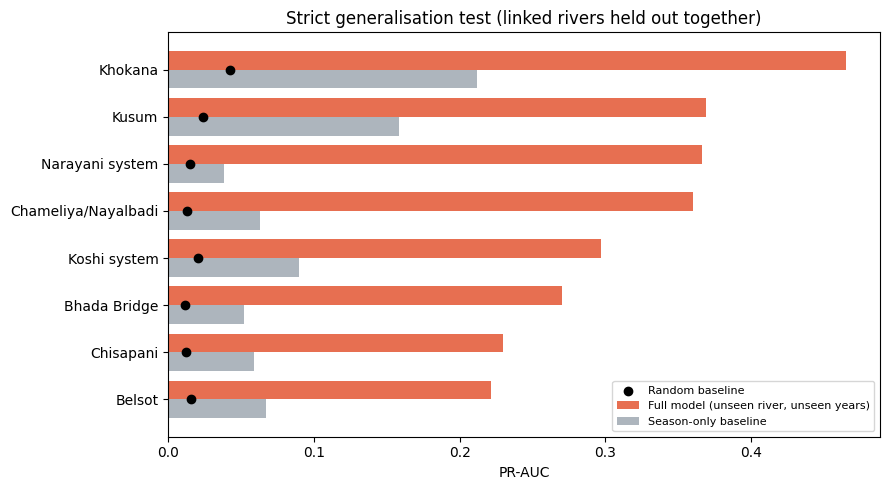

In [22]:
# Grouping is for the reading of the hydrology (Trishuli/Bhote Koshi flows into the Narayani at Devghat;
GROUPS = {"Devghat": "Narayani system", "Rasuwagadhi": "Narayani system",
          "Bahrabise": "Koshi system", "Chatara": "Koshi system"}

d = df.dropna(subset=["y_within2"] + FULL).copy()
d["grp"] = d["location"].map(GROUPS).fillna(d["location"])
rows = []
for gname in d["grp"].unique():
    held = d["grp"] == gname
    for scheme in ["spatial only", "spatial + temporal"]:
        if scheme == "spatial only":
            tr, te = d[~held], d[held]
        else:
            tr, te = d[~held & (d["date"] < CUTOFF)], d[held & (d["date"] >= CUTOFF)]
        if te["y_within2"].sum() < 3 or tr["y_within2"].sum() < 10:
            continue
        p_full = make_model().fit(tr[FULL], tr["y_within2"]).predict_proba(te[FULL])[:, 1]
        p_seas = make_model().fit(tr[SEASON], tr["y_within2"]).predict_proba(te[SEASON])[:, 1]
        base = te["y_within2"].mean()
        ap_full = average_precision_score(te["y_within2"], p_full)
        rows.append({"held_out": gname, "scheme": scheme, "positives": int(te["y_within2"].sum()),
                     "base_rate": base, "PR_AUC_full": ap_full,
                     "PR_AUC_season_only": average_precision_score(te["y_within2"], p_seas),
                     "lift_full": ap_full / base})
lolo2 = pd.DataFrame(rows)
display(lolo2.pivot(index="held_out", columns="scheme",
                    values=["positives", "PR_AUC_full", "PR_AUC_season_only", "lift_full"]).round(3))

piv = lolo2[lolo2.scheme == "spatial + temporal"].set_index("held_out").sort_values("PR_AUC_full")
plt.figure(figsize=(9, 5))
yy = np.arange(len(piv))
plt.barh(yy + 0.2, piv["PR_AUC_full"], 0.4, label="Full model (unseen river, unseen years)", color="#e76f51")
plt.barh(yy - 0.2, piv["PR_AUC_season_only"], 0.4, label="Season-only baseline", color="#adb5bd")
plt.scatter(piv["base_rate"], yy, color="k", zorder=3, label="Random baseline")
plt.yticks(yy, piv.index); plt.xlabel("PR-AUC"); plt.legend(fontsize=8)
plt.title("Strict generalisation test (linked rivers held out together)")
plt.tight_layout(); plt.show()
# Caveat to write in Limitations: q_to_thr_tr uses the held-out river's own pre-2025 95th percentile,
# i.e. the model assumes you have ~2 years of flow history for the new river.


## 7. Final output: Flood Risk Scorecard
One table ranking each location on flashiness, flood frequency, peak severity and how sensitive
it is to wet soil.

In [23]:
score = summary[["river", "elevation_m", "flashiness", "flood_days", "peak_to_median", "response_lag_days"]].copy()
score["wet_soil_sensitivity"] = pivot["wet_minus_dry"]
norm = lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9)
score["risk_score"] = (0.35 * norm(score["flashiness"]) + 0.25 * norm(score["peak_to_median"]) +
                       0.20 * norm(score["flood_days"]) + 0.20 * norm(score["wet_soil_sensitivity"].fillna(0))) * 100
score = score.sort_values("risk_score", ascending=False)
display(score.style.background_gradient(subset=["risk_score"], cmap="Reds").format(precision=2))

,river,elevation_m,flashiness,flood_days,peak_to_median,response_lag_days,wet_soil_sensitivity,risk_score
location,,,,,,,,
Khokana,Bagmati,1315,0.51,67,261.86,1,-0.11,94.87
Kusum,West Rapti,230,0.22,67,188.37,1,-0.73,52.57
Chatara,Saptakoshi,153,0.16,66,83.11,1,0.04,45.00
Devghat,Narayani,603,0.05,67,24.16,1,-0.01,40.10
Bhada Bridge,Babai,157,0.16,65,120.90,1,0.10,39.96
Rasuwagadhi,Bhote Koshi,1749,0.07,67,13.22,1,-0.08,38.58
Bahrabise,Bhote Koshi,1870,0.09,67,21.63,1,-0.26,37.06
Chameliya/Nayalbadi,Chamelia,685,0.03,67,8.81,2,-0.02,36.84
Belsot,Kamala,188,0.06,66,22.37,1,0.12,33.13


## 8. Findings
- **Fastest / slowest rivers:** Khokana is by far the flashiest (index 0.51), then Kusum (0.22), Chatara and
  Bhada Bridge (0.16). Chameliya (0.03), Devghat (0.05), Belsot (0.06) and Rasuwagadhi (0.07) are the most
  sluggish. 8 of 10 rivers respond to rain within 1 day; Chameliya is slower (peak at 2 days, tail to ~4),
  and Devghat is split between 1 and 2 days. [Caveat: gridded discharge, magnitudes need validating.]
- **Does wet soil amplify rain?** No support in this analysis. Wet-soil heavy-rain days showed *lower* 3-day
  log surge than dry-soil days (≈0.18 vs 0.28; Mann–Whitney Wet>Dry p = 0.9986). This is likely a
  seasonal/baseline artefact of the log-ratio metric, not evidence against the mechanism.
  [Replace with the clustered regression coefficient on z_soil, with CI, from the fixed test.]
- **Typical flood recipe:** Short rain pulse, not a long build-up. Rainfall anomaly starts rising 2 days before
  onset (≈+1.4 SD), peaks the day before (≈+2.9 SD), and discharge jumps on onset day (≈+2.7 SD). Soil moisture
  stays elevated (+1 to +1.3 SD) throughout rather than changing. [Re-check after de-seasonalising.]
- **Model:** Predicting flood onset within 2 days, PR-AUC is 0.35 (weather + discharge) vs 0.26 (weather only)
  vs 0.15 (discharge only) vs 0.022 random (~16x lift). Discharge alone is weakest because river flow
  has not yet moved on the days before onset; weather captures the rain pulse. Whether weather adds
  *lead time* is not yet shown: it needs the per-horizon (t+1/t+2/t+3) comparison with confidence intervals.
- **Unseen-river test:** All 10 rivers beat random (PR-AUC 0.31–0.53, 8–36x lift). Best: Bhada Bridge, Chisapani,
  Bahrabise. Weakest: Chameliya and Devghat, the slower-responding rivers, suggesting the pooled model learned
  a fast rain-to-flood pattern. [Re-run with grouped, time-respecting splits and without elevation.]
- **Limitations:** only ~3.7 years (4 monsoons, the last incomplete); ~60 independent flood events in the test
  set; "flood" is a 95th-percentile definition (so flood-day counts are ~67 per river by construction),
  not an official DHM danger level; discharge is modelled/gridded and its magnitudes look too low for
  several major rivers; the model uses same-day observed rain, so it is a nowcast, not a forecast.